In [1]:
!pip install diffusers transformers accelerate torch

In [4]:
from google.colab import userdata
import torch

# This pulls the value securely from the 'HF_TOKEN' secret you just created
token = userdata.get('HF_TOKEN')

# Use it in your pipeline (Note: 'token' is the modern argument name)
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    token=token
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/30 [00:00<?, ?it/s]

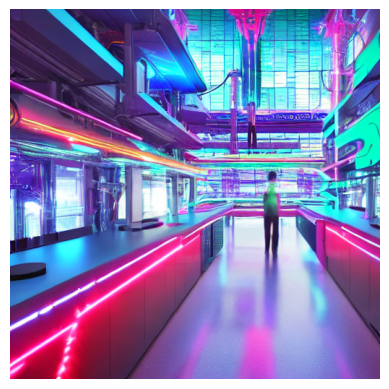

In [3]:
import matplotlib.pyplot as plt

# 1. Define your prompt
prompt = "A high-tech laboratory in a futuristic city, cyberpunk style, neon lights, 8k resolution"

# 2. Run the pipeline
# We use 'with torch.inference_mode():' to save memory
import torch
with torch.inference_mode():
    result = pipe(prompt, num_inference_steps=30)
    image = result.images[0]

# 3. Save and show
image.save("output.png")

plt.imshow(image)
plt.axis("off")
plt.show()